In [50]:
import pandas as pd
import numpy as np

splits = {'train': 'es/train.jsonl.gz', 'validation': 'es/validation.jsonl.gz', 'test': 'es/test.jsonl.gz'}
df = pd.read_json("hf://datasets/goosmanlei/amazon_reviews_multi/" + splits["train"], lines=True)

In [51]:
df.head()

,review_id,product_id,reviewer_id,stars,review_body,review_title,language,product_category
0,es_0491108,product_es_0296024,reviewer_es_0999081,1,Nada bueno se me fue ka pantalla en menos de 8...,television Nevir,es,electronics
1,es_0869872,product_es_0922286,reviewer_es_0216771,1,"Horrible, nos tuvimos que comprar otro porque ...",Dinero tirado a la basura con esta compra,es,electronics
2,es_0811721,product_es_0474543,reviewer_es_0929213,1,Te obligan a comprar dos unidades y te llega s...,solo llega una unidad cuando te obligan a comp...,es,drugstore
3,es_0359921,product_es_0656090,reviewer_es_0224702,1,"No entro en descalificar al vendedor, solo pue...",PRODUCTO NO RECIBIDO.,es,wireless
4,es_0068940,product_es_0662544,reviewer_es_0224827,1,Llega tarde y co la talla equivocada,Devuelto,es,shoes


In [52]:
df.tail()

,review_id,product_id,reviewer_id,stars,review_body,review_title,language,product_category
199995,es_0715276,product_es_0317036,reviewer_es_0643604,5,Mando funciona perfectamente y cumple con toda...,Tal y como se describe,es,electronics
199996,es_0085190,product_es_0622919,reviewer_es_0466173,5,"Compré la batería con cierta reticencia, pero ...",Funciona perfectamente,es,electronics
199997,es_0484496,product_es_0358101,reviewer_es_0330744,5,Buena calidad. Satisfecha con la compra.,Buena calidad.,es,apparel
199998,es_0930141,product_es_0788855,reviewer_es_0694290,5,Perfecto para el cumple de mi hijo,Recomendado,es,toy
199999,es_0859809,product_es_0378794,reviewer_es_0141717,5,"Súper bien! Las brochas son buenas, no sé meno...",Preciosas,es,home


In [53]:
df.shape

(200000, 8)

In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 8 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   review_id         200000 non-null  object
 1   product_id        200000 non-null  object
 2   reviewer_id       200000 non-null  object
 3   stars             200000 non-null  int64 
 4   review_body       200000 non-null  object
 5   review_title      200000 non-null  object
 6   language          200000 non-null  object
 7   product_category  200000 non-null  object
dtypes: int64(1), object(7)
memory usage: 12.2+ MB


In [55]:
df.isnull().sum()

review_id           0
product_id          0
reviewer_id         0
stars               0
review_body         0
review_title        0
language            0
product_category    0
dtype: int64

In [56]:
df['stars'].value_counts().sort_index()

stars
1    40000
2    40000
3    40000
4    40000
5    40000
Name: count, dtype: int64

In [57]:
# Tenemos 200.000 registros completos. 
# Las 8 columnas tienen 200000 non-null, así que no tenemos valores nulos. No necesitamos dropna().
# Stars ya es numérica (int64). No necesitamos convertirla.

# La base de datos está perfectamente balanceada por estrellas:

#⭐              1	40.000	20%
#⭐⭐           2	  40.000	20%
#⭐⭐⭐         3	 40.000	20%
#⭐⭐⭐⭐      4	40.000	20%
#⭐⭐⭐⭐⭐    5	  40.000	20%

In [58]:
# Conversión

# De 1–2 estrellas → Negativo
# De 3 estrellas → Neutral
# De 4–5 estrellas → Positivo

# En total tendríamos: 80.000 negativos — 40.000 neutrales — 80.000 positivos 
# Se desbalancea un poco la base de datos

# Para tenerla balanceada se tomarán 3000 comentarios: 1.000 negativos + 1.000 neutrales + 1.000 positivos

In [59]:
df['sentimiento'] = 'neutral'

df.loc[df['stars'] <= 2, 'sentimiento'] = 'negativo'
df.loc[df['stars'] >= 4, 'sentimiento'] = 'positivo'

In [60]:
df['sentimiento'].value_counts()

sentimiento
negativo    80000
positivo    80000
neutral     40000
Name: count, dtype: int64

In [61]:
# Tomamos una muestra aleatoria de los comentarios

In [62]:
negativos = df[df['sentimiento'] == 'negativo'].sample(n=1000, random_state=42)

neutrales = df[df['sentimiento'] == 'neutral'].sample(n=1000, random_state=42)

positivos = df[df['sentimiento'] == 'positivo'].sample(n=1000, random_state=42)

In [63]:
# Colocamos los comentarios en la base de datos

df_muestra = pd.concat([negativos, neutrales, positivos])

In [64]:
# Mezclamos aleatoriamente las filas del conjunto de datos y reordenamos sus índices

df_muestra = df_muestra.sample(frac=1, random_state=42).reset_index(drop=True)

In [65]:
print(df_muestra.shape)

print(df_muestra['sentimiento'].value_counts())

(3000, 9)
sentimiento
neutral     1000
negativo    1000
positivo    1000
Name: count, dtype: int64


In [66]:
# Simplificamos la base de datos quitando las columnas que no necesitamos y dejamos solo las útiles para el proyecto

# review_body → comentario que leerá mmBERT
# stars → puntuación original de Amazon
# sentimiento → nuestra etiqueta real
# product_category → categoría del producto

df_muestra = df_muestra[['review_body', 'stars', 'sentimiento', 'product_category']]

df_muestra.head()

,review_body,stars,sentimiento,product_category
0,"No me ha terminado de convencer, algunos de lo...",3,neutral,camera
1,Robusta y adecuada para los niños Per no me en...,3,neutral,wireless
2,Precio... Calidad.. Son buenas,3,neutral,sports
3,TOTALMENTE DESCONFORME ..SE TRASPASA AL MOMENT...,1,negativo,home
4,Solo llevo usando la batería 1 semana y por el...,4,positivo,pc


In [67]:
df_muestra['longitud'] = df_muestra['review_body'].str.len()

df_muestra['longitud'].describe()

count    3000.000000
mean      151.097333
std       127.084263
min        20.000000
25%        67.750000
50%       120.000000
75%       188.000000
max      1033.000000
Name: longitud, dtype: float64

In [68]:
df_muestra['product_category'].value_counts()

product_category
home                        414
wireless                    399
sports                      204
toy                         179
pc                          169
home_improvement            147
electronics                 133
kitchen                     116
beauty                      114
automotive                  102
apparel                      94
book                         85
furniture                    81
office_product               77
baby_product                 76
drugstore                    71
other                        65
luggage                      59
lawn_and_garden              59
pet_products                 52
personal_care_appliances     50
camera                       47
shoes                        34
video_games                  30
musical_instruments          30
digital_ebook_purchase       26
jewelry                      26
watch                        22
industrial_supplies          22
grocery                      17
Name: count, dtype: int

In [ ]:
# Ploteamos las categorías con más comentarios

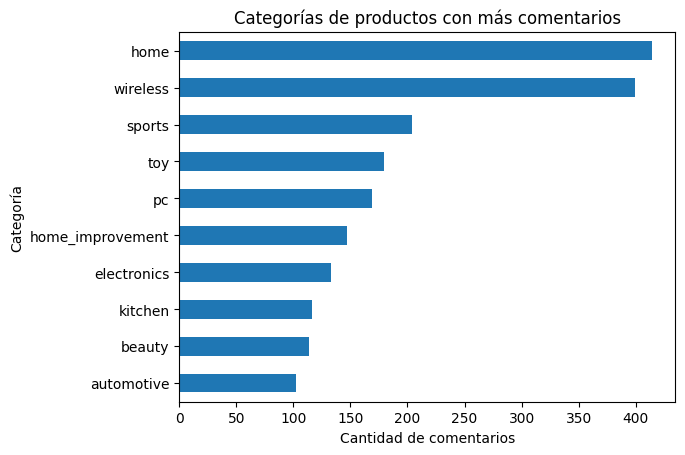

In [69]:
import matplotlib.pyplot as plt

categorias = df_muestra['product_category'].value_counts().head(10)

categorias.plot(kind='barh')

plt.title('Categorías de productos con más comentarios')
plt.xlabel('Cantidad de comentarios')
plt.ylabel('Categoría')
plt.gca().invert_yaxis()
plt.show()

In [ ]:
# Transformer - Análisis de sentimientos

In [70]:
from transformers import pipeline

modelo_sentimientos = pipeline(
    "text-classification",
    model="clapAI/mmBERT-small-multilingual-sentiment"
)

Device set to use cuda:0


In [71]:
comentario = df_muestra['review_body'].iloc[0]

print(comentario)

No me ha terminado de convencer, algunos de los artículos no son de muy buena calidad, en este aspecto podrían mejorarlos, calidad precio no está mal.


In [72]:
resultado = modelo_sentimientos(comentario)

print(resultado)

[{'label': 'neutral', 'score': 0.5865458250045776}]


In [73]:
# comentarios convierte nuestra columna en una lista de 3.000 textos
# batch_size=32 hace que procese 32 comentarios por lote
# truncation=True evita problemas si encuentra algún comentario demasiado largo para el modelo

comentarios = df_muestra['review_body'].tolist()

resultados = modelo_sentimientos(
    comentarios,
    batch_size=32,
    truncation=True
)

In [74]:
df_muestra['sentimiento_predicho'] = [
    resultado['label'] for resultado in resultados
]

df_muestra['confianza'] = [
    resultado['score'] for resultado in resultados
]

In [75]:
df_muestra[
    ['review_body', 'sentimiento', 'sentimiento_predicho', 'confianza']
].head(10)

,review_body,sentimiento,sentimiento_predicho,confianza
0,"No me ha terminado de convencer, algunos de lo...",neutral,neutral,0.586546
1,Robusta y adecuada para los niños Per no me en...,neutral,neutral,0.712300
2,Precio... Calidad.. Son buenas,neutral,positive,0.811433
3,TOTALMENTE DESCONFORME ..SE TRASPASA AL MOMENT...,negativo,negative,0.964897
4,Solo llevo usando la batería 1 semana y por el...,positivo,neutral,0.475851
5,"Llego bien de tiempo, bien de talla y tejido t...",neutral,positive,0.852191
6,"El color muy bonito, pero me molestan en el oj...",neutral,negative,0.865891
7,Auriculares de uso diario con buena calidad de...,positivo,positive,0.964566
8,"producto no entregado, no puedo valorar",negativo,negative,0.988766
9,Me costo.. acceder.. ni pc por lan.. ni por wi...,positivo,positive,0.668021


In [76]:
# Traducimos las predicciones

df_muestra['sentimiento_predicho'] = df_muestra['sentimiento_predicho'].replace({
    'negative': 'negativo',
    'neutral': 'neutral',
    'positive': 'positivo'
})

df_muestra[
    ['sentimiento', 'sentimiento_predicho', 'confianza']
].head(10)

,sentimiento,sentimiento_predicho,confianza
0,neutral,neutral,0.586546
1,neutral,neutral,0.712300
2,neutral,positivo,0.811433
3,negativo,negativo,0.964897
4,positivo,neutral,0.475851
5,neutral,positivo,0.852191
6,neutral,negativo,0.865891
7,positivo,positivo,0.964566
8,negativo,negativo,0.988766
9,positivo,positivo,0.668021


In [77]:
df_muestra['sentimiento_predicho'].value_counts()

sentimiento_predicho
negativo    1253
positivo     989
neutral      758
Name: count, dtype: int64

In [78]:
# Porcentaje de Accuracy

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    df_muestra['sentimiento'],
    df_muestra['sentimiento_predicho']
)

print("Accuracy:", accuracy)

Accuracy: 0.7433333333333333


In [79]:
# Reporte

from sklearn.metrics import classification_report

reporte = classification_report(
    df_muestra['sentimiento'],
    df_muestra['sentimiento_predicho']
)

print(reporte)

              precision    recall  f1-score   support

    negativo       0.70      0.88      0.78      1000
     neutral       0.68      0.51      0.58      1000
    positivo       0.84      0.83      0.84      1000

    accuracy                           0.74      3000
   macro avg       0.74      0.74      0.74      3000
weighted avg       0.74      0.74      0.74      3000



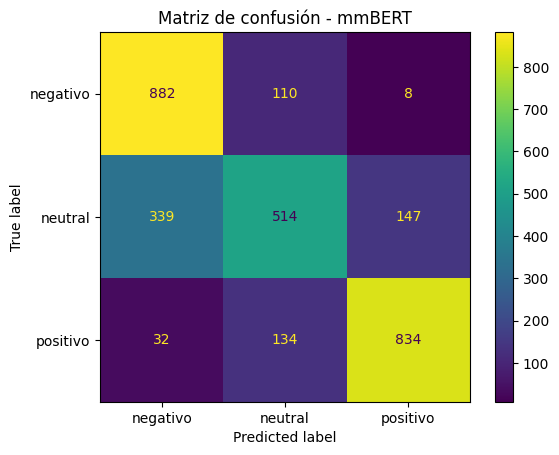

In [80]:
# Matriz de confusión

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

clases = ['negativo', 'neutral', 'positivo']

matriz = confusion_matrix(
    df_muestra['sentimiento'],
    df_muestra['sentimiento_predicho'],
    labels=clases
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=matriz,
    display_labels=clases
)

disp.plot()

plt.title('Matriz de confusión - mmBERT')
plt.show()

In [ ]:
# El modelo mmBERT obtuvo una exactitud global del 74,33 %. 
# Presentó un mejor desempeño identificando comentarios negativos y positivos, con un recall del 88 % y 83 %, respectivamente. 
# La principal dificultad se encontró en los comentarios neutrales, de los cuales identificó correctamente el 51 %. 
# La mayor confusión ocurrió entre las clases neutral y negativa.

In [81]:
df["product_category"].sort_values().unique()

array(['apparel', 'automotive', 'baby_product', 'beauty', 'book',
       'camera', 'digital_ebook_purchase', 'drugstore', 'electronics',
       'furniture', 'grocery', 'home', 'home_improvement',
       'industrial_supplies', 'jewelry', 'kitchen', 'lawn_and_garden',
       'luggage', 'musical_instruments', 'office_product', 'other', 'pc',
       'personal_care_appliances', 'pet_products', 'shoes', 'sports',
       'toy', 'video_games', 'watch', 'wireless'], dtype=object)

In [82]:
np.random.seed(42)

fecha_inicio = pd.Timestamp("2026-06-01")
fecha_fin = pd.Timestamp("2026-09-18")

dias = (fecha_fin - fecha_inicio).days

df_muestra["fecha"] = (
    fecha_inicio
    + pd.to_timedelta(
        np.random.randint(0, dias + 1, size=len(df_muestra)),
        unit="D"
    )
)

In [83]:
df_muestra[
    ["fecha", "review_body", "product_category",
     "sentimiento_predicho", "confianza"]
].head()

,fecha,review_body,product_category,sentimiento_predicho,confianza
0,2026-09-11,"No me ha terminado de convencer, algunos de lo...",camera,neutral,0.586546
1,2026-07-22,Robusta y adecuada para los niños Per no me en...,wireless,neutral,0.712300
2,2026-09-01,Precio... Calidad.. Son buenas,sports,positivo,0.811433
3,2026-06-15,TOTALMENTE DESCONFORME ..SE TRASPASA AL MOMENT...,home,negativo,0.964897
4,2026-09-15,Solo llevo usando la batería 1 semana y por el...,pc,neutral,0.475851


In [84]:
df_amazon = df_muestra[
    [
        "fecha",
        "review_body",
        "product_category",
        "sentimiento_predicho",
        "confianza"
    ]
].copy()

In [85]:
df_amazon = df_amazon.rename(
    columns={
        "review_body": "comentario",
        "product_category": "categoria",
        "sentimiento_predicho": "sentimiento"
    }
)

In [86]:
df_amazon["sentimiento"] = df_amazon["sentimiento"].replace({
    "negativo": "negative",
    "neutral": "neutral",
    "positivo": "positive"
})

In [87]:
df_amazon.head()

,fecha,comentario,categoria,sentimiento,confianza
0,2026-09-11,"No me ha terminado de convencer, algunos de lo...",camera,neutral,0.586546
1,2026-07-22,Robusta y adecuada para los niños Per no me en...,wireless,neutral,0.712300
2,2026-09-01,Precio... Calidad.. Son buenas,sports,positive,0.811433
3,2026-06-15,TOTALMENTE DESCONFORME ..SE TRASPASA AL MOMENT...,home,negative,0.964897
4,2026-09-15,Solo llevo usando la batería 1 semana y por el...,pc,neutral,0.475851


In [88]:
print(df_amazon.shape)

print(df_amazon["sentimiento"].value_counts())

(3000, 5)
sentimiento
negative    1253
positive     989
neutral      758
Name: count, dtype: int64


In [89]:
df_amazon.to_csv(
    "comentarios_amazon.csv",
    index=False
)

In [90]:
df_prueba = pd.read_csv("comentarios_amazon.csv")

print(df_prueba.shape)
df_prueba.head()

(3000, 5)


,fecha,comentario,categoria,sentimiento,confianza
0,2026-09-11,"No me ha terminado de convencer, algunos de lo...",camera,neutral,0.586546
1,2026-07-22,Robusta y adecuada para los niños Per no me en...,wireless,neutral,0.712300
2,2026-09-01,Precio... Calidad.. Son buenas,sports,positive,0.811433
3,2026-06-15,TOTALMENTE DESCONFORME ..SE TRASPASA AL MOMENT...,home,negative,0.964897
4,2026-09-15,Solo llevo usando la batería 1 semana y por el...,pc,neutral,0.475851


In [91]:
df_comentarios = pd.read_csv("comentarios.csv")

print(df_comentarios.shape)
df_comentarios.head()

(3000, 5)


,fecha,comentario,categoria,sentimiento,confianza
0,2026-09-11,"No me ha terminado de convencer, algunos de lo...",camera,neutral,0.586546
1,2026-07-22,Robusta y adecuada para los niños Per no me en...,wireless,neutral,0.712300
2,2026-09-01,Precio... Calidad.. Son buenas,sports,positive,0.811433
3,2026-06-15,TOTALMENTE DESCONFORME ..SE TRASPASA AL MOMENT...,home,negative,0.964897
4,2026-09-15,Solo llevo usando la batería 1 semana y por el...,pc,neutral,0.475851


In [92]:
print(df_comentarios.tail())

           fecha                                         comentario  \
2995  2026-07-25                         No queda bien en los lados   
2996  2026-06-02  No es que esté mal o me haya decepcionado el p...   
2997  2026-08-01  El paquete viene muy bien y completo, con much...   
2998  2026-08-30  Me ha faltado info, no lleva cargador incorpor...   
2999  2026-06-21  El color de la carcasa donde encaja la Miband2...   

        categoria sentimiento  confianza  
2995     wireless    negative   0.621527  
2996       sports     neutral   0.634527  
2997  electronics    negative   0.462217  
2998      luggage     neutral   0.559536  
2999       sports    negative   0.786679  


In [93]:
print(df_comentarios["categoria"].tail())

2995       wireless
2996         sports
2997    electronics
2998        luggage
2999         sports
Name: categoria, dtype: object


In [94]:
df_comentarios = pd.read_csv("comentarios.csv")

df_comentarios = df_comentarios.iloc[:3000]

df_comentarios.to_csv(
    "comentarios.csv",
    index=False
)

In [95]:
print(df_comentarios.shape)

(3000, 5)


In [96]:
df_comentarios = pd.read_csv("comentarios.csv")

print(df_comentarios.shape)
print(df_comentarios.tail())

(3001, 5)
                    fecha                                         comentario  \
2996           2026-06-02  No es que esté mal o me haya decepcionado el p...   
2997           2026-08-01  El paquete viene muy bien y completo, con much...   
2998           2026-08-30  Me ha faltado info, no lleva cargador incorpor...   
2999           2026-06-21  El color de la carcasa donde encaja la Miband2...   
3000  18/09/2026 18:05:31  Los nike mercurial vapor están geniales, voy a...   

        categoria sentimiento  confianza  
2996       sports     neutral   0.634527  
2997  electronics    negative   0.462217  
2998      luggage     neutral   0.559536  
2999       sports    negative   0.786679  
3000        shoes    positive   0.975685  
